# **Aprendizado de Máquina** <BR>**Aula 03** - Variáveis categóricas, métricas e validação

# **Exemplo 1**: previsão do peso de estudantes em função de altura e gênero

## **1)** Importação de bibliotecas e classes

In [1]:
import numpy as np    # Operações numéricas em geral
import pandas as pd   # Leitura de dados e operações em DataFrames
from matplotlib import pyplot as plt    # Geração de gráficos

from sklearn.linear_model import LinearRegression   # Regressão linear

## **2)** Leitura de dados e exploração inicial

### **2.1)** Criação (manual) e análise do *DataFrame*

In [2]:
# "Leitura" dos dados: atribuição manual de valores
# de altura (cm), peso (kg) e genero (0 = F, 1 = M)
Dados = np.array([[170,84,1],
                  [175,88,1],
                  [176,62,1],
                  [170,60,0],
                  [179,59,1],
                  [162,63,0],
                  [169,76,1],
                  [180,130,1],
                  [175,60,1],
                  [171,59,1],
                  [170,55,1],
                  [172,63,1],
                  [181,74,1],
                  [191,65,1],
                  [171,70,1],
                  [175,80,1],
                  [173,60,1],
                  [180,85,1],
                  [172,75,1],
                  [160,60,0],
                  [167,72,1],
                  [173,53,1],
                  [186,75,1],
                  [195,75,1],
                  [177,74,1],
                  [175,70,1],
                  [173,72,1],
                  [171,70,1],
                  [170,70,1],
                  [174,89,1],
                  [190,110,1],
                  [177,60,1],
                  [180,56,1],
                  [158,50,0],
                  [173,80,1],
                  [173,77,1],
                  [177,85,1],
                  [170,81,1],
                  [171,56,1],
                  [178,80,1],
                  [183,84,1],
                  [181,55,1],
                  [180,70,1],
                  [168,72,1],
                  [156,51,0],
                  [167,56,0],
                  [167,52,0],
                  [173,75,1],
                  [189,83,1],
                  [185,65,1],
                  [182,74,1],
                  [180,105,1],
                  [170,80,1],
                  [182,80,1],
                  [172,67,1],
                  [174,69,1],
                  [168,49,0],
                  [180,107,1],
                  [170,72,1],
                  [189,80,1],
                  [176,82,1],
                  [170,84,1],
                  [177,90,1],
                  [175,102,1],
                  [172,51,1],
                  [187,80,1]])

# Criação manual do DataFrame e exibição
df = pd.DataFrame(data = Dados,columns = ['Altura','Peso','Genero'])
display(df)

,Altura,Peso,Genero
0,170,84,1
1,175,88,1
2,176,62,1
3,170,60,0
4,179,59,1
...,...,...,...
61,170,84,1
62,177,90,1
63,175,102,1
64,172,51,1


In [3]:
# Classe de dados dos atributos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Altura  66 non-null     int64
 1   Peso    66 non-null     int64
 2   Genero  66 non-null     int64
dtypes: int64(3)
memory usage: 1.7 KB


In [4]:
# "Novidade": tabela de contagem de valores
# Codificação do gênero: 0 = F, 1 = M
df['Genero'].value_counts()

,count
Genero,
1,58
0,8


### **2.2)** Análise gráfica

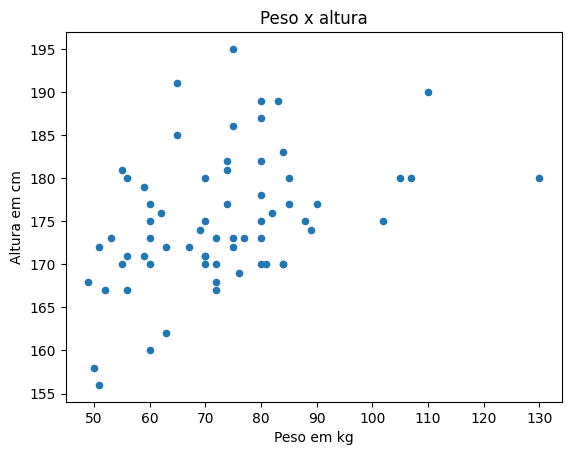

In [5]:
# Diagrama de dispersão de peso e altura SEM
# diferenciação de gênero
df.plot.scatter(x = 'Peso',y = 'Altura')
plt.title("Peso x altura")
plt.xlabel("Peso em kg")
plt.ylabel("Altura em cm")
plt.show()

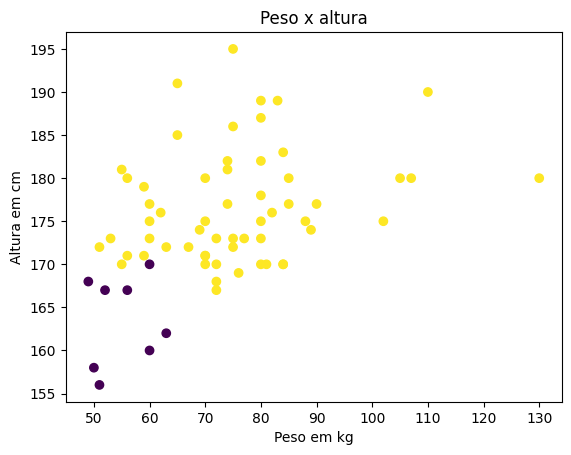

In [6]:
# Diagrama de dispersão de peso x altura COM
# diferenciação de gênero pela COR do ponto
plt.scatter(x = df['Peso'],y = df['Altura'],c = df['Genero'])
plt.title("Peso x altura")
plt.xlabel("Peso em kg")
plt.ylabel("Altura em cm")
plt.show()

## **3)** Seleção de variáveis

In [7]:
y = df['Peso']                # Resposta: peso
X = df[['Altura','Genero']]   # Regressores: altura e gênero

## **4)** Treinamento do modelo (regressão linear múltipla)

In [8]:
# Forma do modelo: y^ = theta_0 + theta_1*x1 + theta_2*x2
# Variáveis: y^ = Peso; x1 = Altura; x2 = Gênero (var. codificada)
reg = LinearRegression()  # Cria instância de um "objeto regressor"
reg.fit(X,y)              # Treina o modelo com TODOS os dados disponíveis

LinearRegression()

## **5)** Exibição dos coeficientes do modelo e da qualidade do ajuste

In [9]:
# Coeficientes
print("Coeficiente linear =",reg.intercept_)  # theta_0
print("Coeficientes angulares =",reg.coef_)   # theta_1, theta_2

Coeficiente linear = -31.219076778861492
Coeficientes angulares = [ 0.52809833 13.40239782]


In [10]:
# Função para o cálculo do coeficiente de determinação da regressão
# linear simples (R^2) ou múltipla (R^2 ajustado):

def R2_R2ajust(regressor,X,y):
  R2 = regressor.score(X,y)  # R^2
  n = len(y)      # Quantidade de dados de treino
  m = X.shape[1]  # Quantidade de variáveis independentes do modelo
  if m == 1:
    return R2   # Regressão simples: retorna R^2
  else:
    return 1-((n-1)/(n-m-1))*(1-R2)  # Regressão múltipla: R^2 ajustado

In [11]:
# Qualidade de ajuste: R^2 AJUSTADO
print("Coeficiente de determinação AJUSTADO =",R2_R2ajust(reg,X,y))

Coeficiente de determinação AJUSTADO = 0.20298020514190107


## **6)** **Bônus**: gráfico das regressões

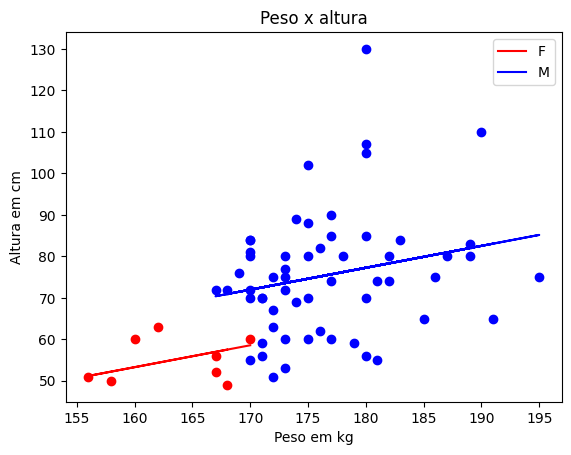

In [12]:
x_F = df[df['Genero'] == 0]           # Seleção de observações do gênero feminino (0)
x_F_prev = x_F[['Altura','Genero']]   # Cria uma estrutura para previsões (duas variáveis)
y_F = reg.predict(x_F_prev)           # Calcula as repostas do modelo para o gênero feminino

x_M = df[df['Genero'] == 1]   # Seleção de observações do gênero masculino (1)
x_M_prev = x_M[['Altura','Genero']]   # Cria uma estrutura para previsões (duas variáveis)
y_M = reg.predict(x_M_prev)       # Calcula as repostas do modelo para o gênero masculino

# Criação dos diagramas de dispersão, usando cores diferentes para cada gênero
plt.scatter(x = x_F['Altura'],y = x_F['Peso'],color = 'red')  # Gênero feminino: pontos vermelhos
plt.scatter(x = x_M['Altura'],y = x_M['Peso'],color = 'blue') # Gênero masculino: pontos azuis
plt.title("Peso x altura")
plt.xlabel("Peso em kg")
plt.ylabel("Altura em cm")

# Inserção das curvas relativas a cada gênero
plt.plot(x_F['Altura'],y_F,color = 'red',label = 'F')    # Gênero feminino: linha vermelha
plt.plot(x_M['Altura'],y_M,color = 'blue',label = 'M')   # Gênero masculino: linha azul
plt.legend()  # Insere a legenda
plt.show()    # "Consolida" a exibição dos gráficos

---
**Fim do Exemplo 1 da Aula 03**

# **Exercício 2**. Validação do modelo do Exercício 1 (avaliação da capacidade de generalização)

## **1)** Validação cruzada *hold-out*

In [13]:
# Separação dos dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# Parâmetros da função 'train_test_split':
# X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# train_size/test_size = percentual de dados de treino/teste. Padrão: 75% (treino) e 25% (teste)

# Divide os dados: 80% para treino ('train_size'), 20% para teste
# IMPORTANTE: sem o controle do parâmetro 'random_state', diferentes partições
# do conjunto de dados serão retornadas a cada execução do método de divisão
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8)

print("Dimensões dos dados de treino:",X_treino.shape)
print("Dimensões dos dados de teste:",X_teste.shape)

Dimensões dos dados de treino: (52, 2)
Dimensões dos dados de teste: (14, 2)


In [14]:
# Treinamento do modelo (apenas) com os dados de treino (80% do total)
reg_treino = LinearRegression()
reg_treino.fit(X_treino,y_treino)

LinearRegression()

In [15]:
# Qualidade do ajuste
print("Coeficiente de determinação AJUSTADO =",R2_R2ajust(reg_treino,X_treino,y_treino))

Coeficiente de determinação AJUSTADO = 0.19520508414254822


In [16]:
# Erros de previsão
# RMSE e MAPE do modelo para os dados de teste

# Cálculo das previsões
y_prev_teste = reg_treino.predict(X_teste)

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

# Principais parâmetros das funções 'root_mean_squared_error' e
# 'mean_absolute_percentage_error':
# y_true = valores reais da variável dependente (y)
# y_pred = valores previstos pelo modelo para a variável dependente

RMSE = root_mean_squared_error(y_true = y_teste,y_pred = y_prev_teste)
MAPE = mean_absolute_percentage_error(y_true = y_teste,y_pred = y_prev_teste)
print("RMSE para os dados de teste =",RMSE)
print("MAPE para os dados de teste =",MAPE)

RMSE para os dados de teste = 13.53867477529705
MAPE para os dados de teste = 0.1448216380751667


## **2)** Validação cruzada *k-folds*

In [17]:
from sklearn.model_selection import cross_val_score

# Parâmetros da função 'cross_val_score':
# estimator = um estimador (neste caso, um objeto da classe 'LinearRegression')
# X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# scoring = texto indicativo da métrica de qualidade a ser calculada
# cv = número [inteiro] de partições (k); valor padrão: k = 5

# Executa a validação cruzada k-folds, com k = 10, avaliando a métrica RMSE
aval = cross_val_score(reg,X,y,cv = 10,scoring = 'neg_root_mean_squared_error')

# Calcula o coeficiente de variação das avaliações = desvio padrão/média
# Critério para o coeficiente de variação:
# Até 20%: variação baixa
# De 20% a 60%: variação moderada
# Acima de 60%: variação alta
M = np.mean(-aval)            # Média das avaliações
DP = np.std(-aval,ddof = 1)   # Desvio padrão (amostral) das avaliações
CV_aval = 100*DP/M            # Coeficiente de variação (%) das avaliações

print("Valores de RMSE obtidos:",-aval)   # Obs: troca o sinal dos valores
print("")   # "Imprime" uma linha em branco
print("RMSE médio =",M)
print("Coeficiente de variação (%) =",CV_aval)

Valores de RMSE obtidos: [11.77523154 23.77074373  7.02294204 10.02340112 16.00091189 12.05173724
  4.17332869 13.53426253 13.30127846 16.79834006]

RMSE médio = 12.845217731030246
Coeficiente de variação (%) = 42.20151831975113


In [18]:
# Executa a validação cruzada, avaliando a métrica MAPE
aval = cross_val_score(reg,X,y,cv = 10,scoring = 'neg_mean_absolute_percentage_error')

# Calcula o coeficiente de variação das avaliações = desvio padrão/média
# Critério para o coeficiente de variação:
# Até 20%: variação baixa
# De 20% a 60%: variação moderada
# Acima de 60%: variação alta
M = np.mean(-aval)            # Média das avaliações
DP = np.std(-aval,ddof = 1)   # Desvio padrão (amostral) das avaliações
CV_aval = 100*DP/M            # Coeficiente de variação (%) das avaliações

print("Valores de MAPE obtidos:",-aval)   # Obs: troca o sinal dos valores
print("")   # "Imprime" uma linha em branco
print("MAPE médio =",M)
print("Coeficiente de variação (%) =",CV_aval)

Valores de MAPE obtidos: [0.15602591 0.24570191 0.08515432 0.12079651 0.17666879 0.15429955
 0.05454174 0.1154625  0.10874387 0.18497534]

MAPE médio = 0.14023704355852082
Coeficiente de variação (%) = 39.24450616301982


---
**Fim dos Exercícios 1 e 2 da Aula 03**